<a href="https://colab.research.google.com/github/kartikdhoke9923/Ai-and-dl/blob/main/Alexnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense ,Activation, Dropout, BatchNormalization
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [5]:
(X_train, y_train), (X_test, y_test) =cifar10.load_data()
# Normalise pixel values
X_train= X_train.astype('float32')/255
X_test=X_test.astype('float32')/255

# One hot encoding the labels
y_train=to_categorical(y_train, 10)
y_test=to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [6]:
model=Sequential()
# layer 1

model.add(Conv2D(96, kernel_size=(3,3), strides=(1,1) ,input_shape=(32,32,3),padding='same'))  # here 96 =filter (or kernel)
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# layer 2
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1) ,input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# layer 3
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1) ,input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))

# layer 4
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1) ,input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))

# layer 5
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1) ,input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

#-------- convolution pooling with activation function done above ---------

# flattening
model.add(Flatten())

# fully connected layer 1
model.add(Dense(1024)) # 1024 neurons
model.add(Activation('relu'))
model.add(Dropout(0.5))         # means 50 % neurons are shutdown

# output layer
model.add(Dense(10))    # 10 classes of data hence
model.add(Activation('softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [8]:
history=model.fit(X_train, y_train, batch_size=128 , epochs=15, validation_split=0.2, verbose=1)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 74ms/step - accuracy: 0.4471 - loss: 1.5758 - val_accuracy: 0.1221 - val_loss: 4.7493
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.6214 - loss: 1.0747 - val_accuracy: 0.3569 - val_loss: 2.7660
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.6994 - loss: 0.8588 - val_accuracy: 0.6522 - val_loss: 1.0977
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.7544 - loss: 0.7048 - val_accuracy: 0.7299 - val_loss: 0.8180
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.7952 - loss: 0.5856 - val_accuracy: 0.7523 - val_loss: 0.7460
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.8281 - loss: 0.4939 - val_accuracy: 0.7439 - val_loss: 0.7720
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.8612 - loss: 0.3998 - val_accuracy: 0.7317 - val_loss: 0.8899
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8880 - loss: 0.3272 - 

In [10]:
test_loss,test_acc= model.evaluate(X_test, y_test)
test_loss,test_acc

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8035 - loss: 0.9417


(0.9416577219963074, 0.8034999966621399)

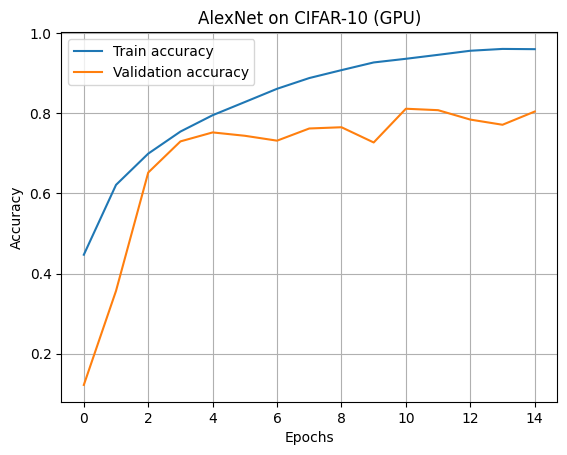

In [11]:
plt.plot(history.history['accuracy'],label='Train accuracy')
plt.plot(history.history['val_accuracy'],label='Validation accuracy')
plt.title("AlexNet on CIFAR-10 (GPU)")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()